# Setup & Imports
First, we import the libraries we need. 
- `numpy`: For numerical operations (we will learn the basics).
- `matplotlib`: To visualize our data and results.
- `sklearn`: For scaling our data.
- `torch` & `torch.nn`: The PyTorch library for building Neural Networks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn

# Make our plots look clean
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Section 1: NumPy Crash Course (The Basics You NEED)

NumPy is the foundation of all data science in Python. PyTorch Tensors work almost identically to NumPy arrays. Let's learn the essential functions we will use today.

---

## 1.1 Creating Arrays

In [2]:
# Creating a 1D array from a Python list
arr_1d = np.array([10, 20, 30, 40, 50])
print("1D Array:", arr_1d)
print("Type:", type(arr_1d))

# Creating a 2D array (a matrix)
arr_2d = np.array([[1, 2, 3], 
                   [4, 5, 6], 
                   [7, 8, 9]])
print("\n2D Array (Matrix):\n", arr_2d)

1D Array: [10 20 30 40 50]
Type: <class 'numpy.ndarray'>

2D Array (Matrix):
 [[1 2 3]
 [4 5 6]
 [7 8 9]]


## 1.2 The Shape Property (Crucial!)

The `.shape` attribute tells you the dimensions of your array. You MUST understand this for machine learning.

In [3]:
print("Shape of 1D array:", arr_1d.shape)   # (5,) means 5 elements, 1 dimension
print("Shape of 2D array:", arr_2d.shape)   # (3, 3) means 3 rows, 3 columns

# Creating a column vector (rows, columns)
col_vector = np.array([[1], [2], [3]])
print("\nColumn vector shape:", col_vector.shape)  # (3, 1)

# Creating a row vector
row_vector = np.array([[1, 2, 3]])
print("Row vector shape:", row_vector.shape)       # (1, 3)

Shape of 1D array: (5,)
Shape of 2D array: (3, 3)

Column vector shape: (3, 1)
Row vector shape: (1, 3)


## 1.3 Generating Ranges (`np.linspace` & `np.arange`)

These are essential for creating test data or plotting smooth curves.

In [4]:
# linspace: evenly spaced numbers over a specified range
# 10 numbers between 0 and 5
linspace_arr = np.linspace(0, 5, 10)
print("linspace(0, 5, 10):\n", linspace_arr)

# arange: numbers with a step size (like Python's range, but returns a NumPy array)
arange_arr = np.arange(0, 10, 2)  # Start=0, Stop=10, Step=2
print("\narange(0, 10, 2):\n", arange_arr)

linspace(0, 5, 10):
 [0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]

arange(0, 10, 2):
 [0 2 4 6 8]


## 1.4 Random Numbers (For generating our dataset)

We use random numbers to create synthetic datasets.

In [5]:
# Set a "seed" so the random numbers are reproducible (always the same)
np.random.seed(42)

# rand: Uniform distribution between 0 and 1
random_uniform = np.random.rand(5)
print("Random uniform (0 to 1):\n", random_uniform)

# randn: Normal distribution (mean=0, std=1)
random_normal = np.random.randn(5)
print("\nRandom normal (mean=0, std=1):\n", random_normal)

# Generating a 2D array of random numbers (3 rows, 2 columns)
random_2d = np.random.rand(3, 2)
print("\nRandom 2D array (3x2):\n", random_2d)

Random uniform (0 to 1):
 [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]

Random normal (mean=0, std=1):
 [ 0.27904129  1.01051528 -0.58087813 -0.52516981 -0.57138017]

Random 2D array (3x2):
 [[0.52475643 0.43194502]
 [0.29122914 0.61185289]
 [0.13949386 0.29214465]]


## 1.5 Indexing & Slicing (Just like lists, but more powerful)

In [6]:
arr = np.array([10, 20, 30, 40, 50, 60])

# Access a single element
print("First element:", arr[0])
print("Last element:", arr[-1])

# Slicing (get a sub-array)
print("Elements from index 2 to 4:", arr[2:5])  # Start at 2, stop before 5
print("Elements from start to index 3:", arr[:4])
print("Elements from index 3 to end:", arr[3:])

# 2D Slicing
matrix = np.array([[1, 2, 3], 
                   [4, 5, 6], 
                   [7, 8, 9]])
print("\nOriginal Matrix:\n", matrix)
print("First row:", matrix[0, :])    # Row 0, all columns
print("Second column:", matrix[:, 1]) # All rows, column 1

First element: 10
Last element: 60
Elements from index 2 to 4: [30 40 50]
Elements from start to index 3: [10 20 30 40]
Elements from index 3 to end: [40 50 60]

Original Matrix:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
First row: [1 2 3]
Second column: [2 5 8]


## 1.6 Element-Wise Math Operations (Vectorization!)

NumPy applies math to **every element** automatically. No loops needed!

In [7]:
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print("a + b =", a + b)
print("a * b =", a * b)          # Element-wise multiplication (NOT matrix multiplication)
print("a ** 2 =", a ** 2)        # Square every element

# Mathematical functions (sin, cos, exp, log...)
angles = np.array([0, np.pi/2, np.pi])
print("\nsin of angles:", np.sin(angles))
print("exp of a:", np.exp(a))

a + b = [11 22 33 44]
a * b = [ 10  40  90 160]
a ** 2 = [ 1  4  9 16]

sin of angles: [0.0000000e+00 1.0000000e+00 1.2246468e-16]
exp of a: [ 2.71828183  7.3890561  20.08553692 54.59815003]


## 1.7 Essential Reshaping Functions: `reshape`, `ravel`, `flatten`

Machine learning models usually expect data in a specific shape (e.g., `(samples, features)`). These functions are your best friends.

In [8]:
arr = np.array([1, 2, 3, 4, 5, 6])
print("Original 1D array:", arr)
print("Shape:", arr.shape)

# reshape(-1, 1) converts to a column vector (rows automatically calculated)
col = arr.reshape(-1, 1)
print("\nReshaped to column (-1, 1):\n", col)
print("Shape:", col.shape)

# reshape(1, -1) converts to a row vector
row = arr.reshape(1, -1)
print("\nReshaped to row (1, -1):\n", row)
print("Shape:", row.shape)

# ravel() flattens a 2D array back to 1D
matrix = np.array([[1, 2, 3], [4, 5, 6]])
flat = matrix.ravel()
print("\nMatrix:\n", matrix)
print("Flattened (ravel):", flat)

Original 1D array: [1 2 3 4 5 6]
Shape: (6,)

Reshaped to column (-1, 1):
 [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape: (6, 1)

Reshaped to row (1, -1):
 [[1 2 3 4 5 6]]
Shape: (1, 6)

Matrix:
 [[1 2 3]
 [4 5 6]]
Flattened (ravel): [1 2 3 4 5 6]


# Section 2: Feature Scaling (The Mandatory Step)

Neural Networks are distance-based algorithms. If one feature is on a scale of 0 to 1000 (e.g., salary) and another is 0 to 1 (e.g., age), the network will think the larger number is "more important".

**The Rule:** We scale all features to have **Mean = 0** and **Standard Deviation = 1**. This is called **Standardization**.

## 2.1 Generate Our Non-Linear Dataset

Let's create our sine wave with noise.

In [9]:
np.random.seed(42)

# 200 points between 0 and 5
X = np.sort(5 * np.random.rand(200, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

print("X shape:", X.shape)  # (200, 1) -> 200 samples, 1 feature
print("y shape:", y.shape)  # (200,) -> 200 target values

# Split into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X shape: (200, 1)
y shape: (200,)


## 2.2 Visualize the Raw Data

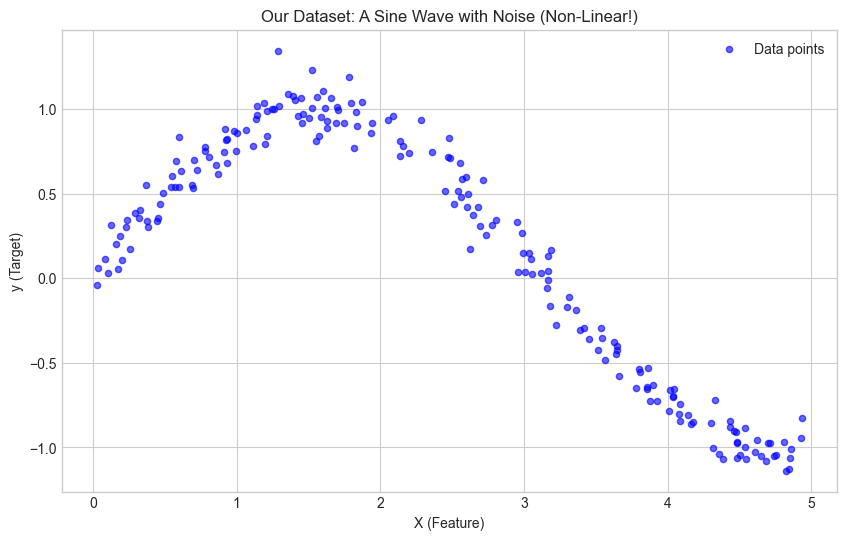

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', s=20, alpha=0.6, label='Data points')
plt.title("Our Dataset: A Sine Wave with Noise (Non-Linear!)")
plt.xlabel("X (Feature)")
plt.ylabel("y (Target)")
plt.legend()
plt.grid(True)
plt.show()

## 2.3 Visualize the SCALE Problem

Let's check the min and max of our data to see why scaling is necessary.

In [11]:
print("X range: [{:.2f}, {:.2f}]".format(X.min(), X.max()))
print("y range: [{:.2f}, {:.2f}]".format(y.min(), y.max()))
print("\nIf we had two features (e.g., X1 age vs X2 salary),")
print("the network would focus on the larger numbers!")
print("We must scale everything to the same range.")

X range: [0.03, 4.93]
y range: [-1.14, 1.35]

If we had two features (e.g., X1 age vs X2 salary),
the network would focus on the larger numbers!
We must scale everything to the same range.


## 2.4 Apply StandardScaler

**Important Rule:** We fit the scaler ONLY on the training data. We must NEVER look at the test data during training (to avoid data leakage). Then, we transform both train and test using the training scaler.

In [12]:
# Create the scaler objects
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit scaler on TRAINING data only
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale the target variable as well (helps the loss function converge smoothly)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

## 2.5 Verify the Scaling

In [13]:
# Check the mean and standard deviation of the scaled training data
print("After Scaling:")
print("X_train_scaled mean:  {:.10f}".format(X_train_scaled.mean()))
print("X_train_scaled std:   {:.2f}".format(X_train_scaled.std()))
print("y_train_scaled mean:  {:.10f}".format(y_train_scaled.mean()))
print("y_train_scaled std:   {:.2f}".format(y_train_scaled.std()))
print("\nMean is effectively 0, and Standard Deviation is 1. Perfect!")

After Scaling:
X_train_scaled mean:  0.0000000000
X_train_scaled std:   1.00
y_train_scaled mean:  0.0000000000
y_train_scaled std:   1.00

Mean is effectively 0, and Standard Deviation is 1. Perfect!


## 2.6 Visualizing the Effect of Scaling

Notice: The *shape* of the data is identical, but the axes have changed.

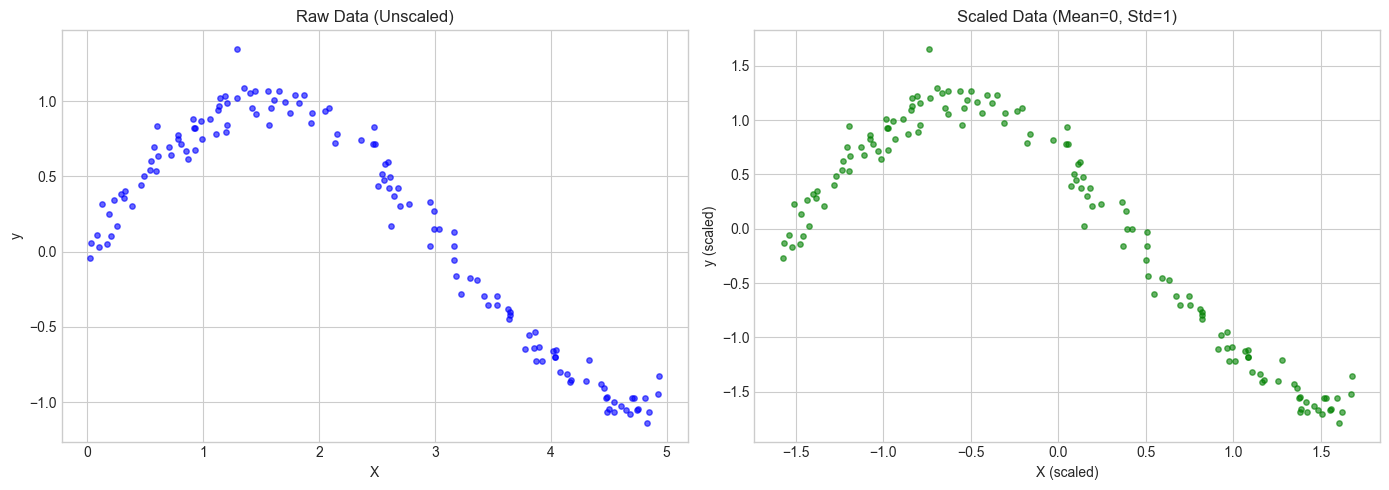

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw data
ax1.scatter(X_train, y_train, color='blue', s=15, alpha=0.6)
ax1.set_title("Raw Data (Unscaled)")
ax1.set_xlabel("X")
ax1.set_ylabel("y")
ax1.grid(True)

# Scaled data
ax2.scatter(X_train_scaled, y_train_scaled, color='green', s=15, alpha=0.6)
ax2.set_title("Scaled Data (Mean=0, Std=1)")
ax2.set_xlabel("X (scaled)")
ax2.set_ylabel("y (scaled)")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Section 3: Model Training with PyTorch

Now we translate our slides into code. We will use PyTorch's `nn.Module` to build our network.

## 3.1 Convert Data to PyTorch Tensors

In [15]:
# Convert our scaled NumPy arrays to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).reshape(-1, 1)

print("Shapes of PyTorch Tensors:")
print("X_train_t:", X_train_t.shape)
print("y_train_t:", y_train_t.shape)
print("X_test_t:", X_test_t.shape)
print("y_test_t:", y_test_t.shape)

Shapes of PyTorch Tensors:
X_train_t: torch.Size([140, 1])
y_train_t: torch.Size([140, 1])
X_test_t: torch.Size([60, 1])
y_test_t: torch.Size([60, 1])


## 3.2 Build the Neural Network (The Building Block from Slide 8)

We define a class that inherits from `nn.Module`.
- `nn.Linear(1, 10)`: The Perceptron (1 input feature → 10 neurons).
- `nn.ReLU()`: The Wrench from **Slide 7**.
- `nn.Linear(10, 1)`: The output layer.

In [16]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # The Perceptron (Linear Layer)
        self.hidden = nn.Linear(1, 10)
        # The Wrench (Activation)
        self.activation = nn.ReLU()
        # The Output Layer
        self.output = nn.Linear(10, 1)
    
    def forward(self, x):
        # This is the LEFT-TO-RIGHT flow from Slide 9
        x = self.hidden(x)       # 1. Linear Math (z = Wx + b)
        x = self.activation(x)   # 2. ReLU (Bend the line!)
        x = self.output(x)       # 3. Final Prediction
        return x

# Create an instance of our model
model = SimpleNN()
print("Our Neural Network Architecture:")
print(model)

Our Neural Network Architecture:
SimpleNN(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=10, out_features=1, bias=True)
)


## 3.3 Define the Loss Function and Optimizer

- **Loss Function (MSE)**: The "Punishment" from **Slide 10**.
- **Optimizer (SGD)**: Handles the "Step down the mountain" from **Slide 13**.

In [17]:
# Hyperparameters (Remember Slide 14?)
learning_rate = 0.01

# The Punishment (Mean Squared Error)
criterion = nn.MSELoss()

# The Optimizer (Takes steps down the mountain)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

print("Learning Rate:", learning_rate)
print("Optimizer: Stochastic Gradient Descent (SGD)")

Learning Rate: 0.01
Optimizer: Stochastic Gradient Descent (SGD)


## 3.4 The Grand Training Loop (Mapping to Slides 9, 10, 12, 13)

This is the circular flowchart from **Slide 13** written in code!
1. **Forward Pass** (Slide 9) → `predictions = model(X_train_t)`
2. **Calculate Loss** (Slide 10) → `loss = criterion(predictions, y_train_t)`
3. **Backpropagate (Blame)** (Slide 12) → `loss.backward()`
4. **Update Weights** (Slide 13) → `optimizer.step()`

In [18]:
epochs = 3000
loss_history = []

print("Starting Training...")
print("-" * 50)

for epoch in range(epochs):
    # 1. FORWARD PASS (Slide 9): Data flows left to right
    predictions = model(X_train_t)
    
    # 2. CALCULATE LOSS (Slide 10): How wrong are we?
    loss = criterion(predictions, y_train_t)
    
    # 3. BACKPROPAGATION (Slide 12): Assign the Blame
    optimizer.zero_grad()   # Clear previous "blame"
    loss.backward()         # Calculate the 'blame' (gradients) for every weight!
    
    # 4. UPDATE WEIGHTS (Slide 13): Take a step down the mountain
    optimizer.step()        # Adjust weights using the learning rate
    
    # Store the loss for visualization
    loss_history.append(loss.item())
    
    # Print progress every 500 epochs
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

print("-" * 50)
print("Training Complete!")

Starting Training...
--------------------------------------------------
Epoch [500/3000], Loss: 0.100083
Epoch [1000/3000], Loss: 0.065378
Epoch [1500/3000], Loss: 0.047562
Epoch [2000/3000], Loss: 0.037864
Epoch [2500/3000], Loss: 0.032260
Epoch [3000/3000], Loss: 0.029218
--------------------------------------------------
Training Complete!


## 3.5 Visualize the "Mountain Descent" (Slide 13)

This plot is the **3D Mountain** from **Slide 13**. The "ball" (our optimizer) rolls downhill with each epoch.

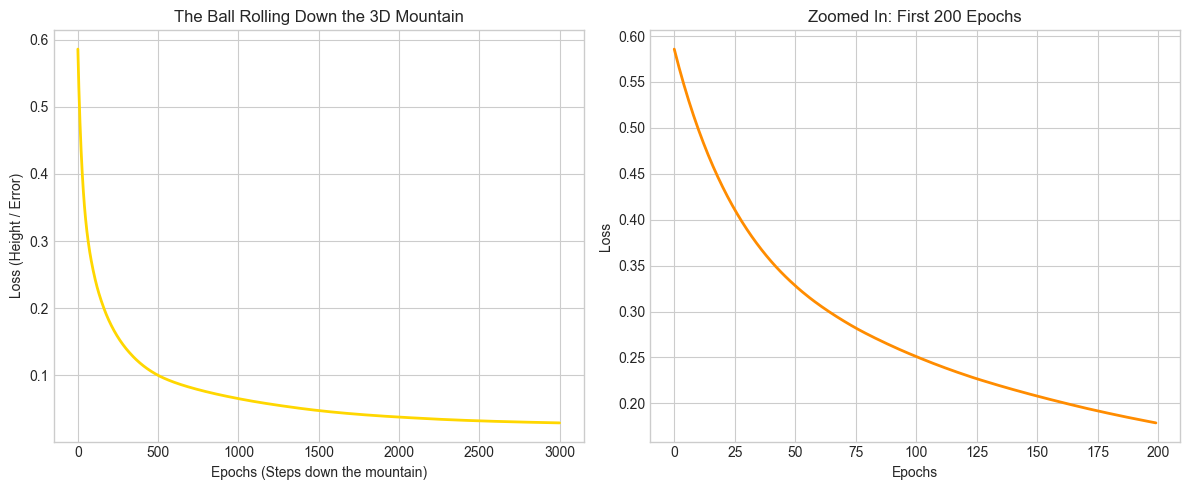

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, color='gold', linewidth=2)
plt.title("The Ball Rolling Down the 3D Mountain")
plt.xlabel("Epochs (Steps down the mountain)")
plt.ylabel("Loss (Height / Error)")
plt.grid(True)

# Zoom in on the first 200 epochs to see the descent clearly
plt.subplot(1, 2, 2)
plt.plot(loss_history[:200], color='darkorange', linewidth=2)
plt.title("Zoomed In: First 200 Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

# Section 4: Testing & Evaluating

We will evaluate our model on the **test data** (data it has NEVER seen before) to check if it truly learned the pattern.

## 4.1 Predict on the Test Set

In [20]:
# Put the model in evaluation mode (disables dropout/batch norm, not needed here but good practice)
model.eval()

# Make predictions on the scaled test data
with torch.no_grad():  # Disable gradient calculation (saves memory)
    predictions_scaled = model(X_test_t)

## 4.2 Inverse Transform the Predictions (Back to Original Scale)

In [21]:
# Convert predictions back to NumPy
predictions_scaled_np = predictions_scaled.numpy().reshape(-1, 1)
y_test_scaled_np = y_test_t.numpy().reshape(-1, 1)

# Inverse transform to get back to the original y scale
predictions = scaler_y.inverse_transform(predictions_scaled_np).ravel()
y_test_actual = scaler_y.inverse_transform(y_test_scaled_np).ravel()

## 4.3 Plot the Smooth Fitted Curve (No Dots!)

To show the curve clearly, we sort the test points by X and draw a continuous line.

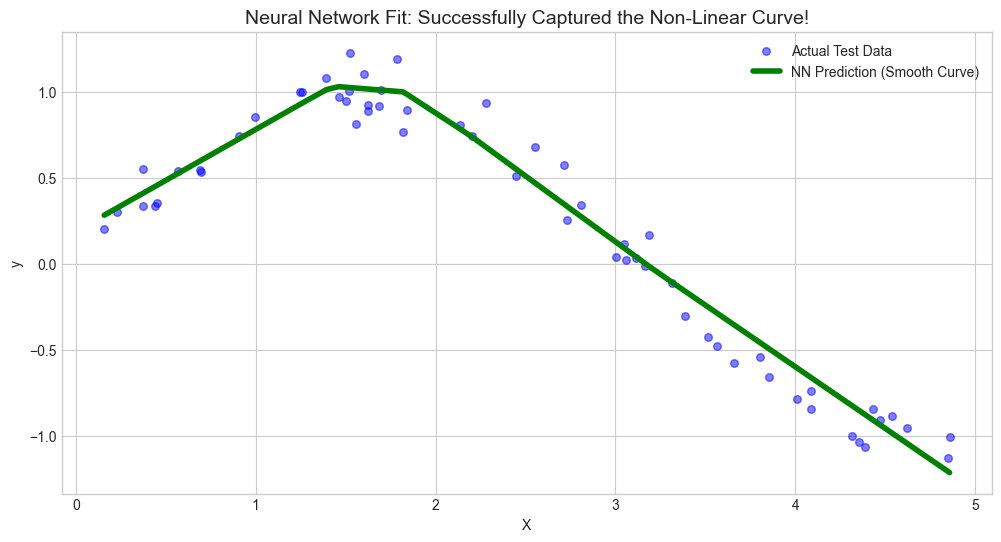

Final Test MSE: 0.015886


In [22]:
# Sort the test data by X so we can draw a smooth curve
sorted_indices = np.argsort(X_test.ravel())
X_test_sorted = X_test[sorted_indices]
predictions_sorted = predictions[sorted_indices]

# Plot the results
plt.figure(figsize=(12, 6))

# 1. The actual test data (scatter)
plt.scatter(X_test, y_test_actual, color='blue', s=30, alpha=0.5, label='Actual Test Data')

# 2. The Neural Network predictions (SMOOTH CURVE)
plt.plot(X_test_sorted, predictions_sorted, color='green', linewidth=4, label='NN Prediction (Smooth Curve)')

plt.title("Neural Network Fit: Successfully Captured the Non-Linear Curve!", fontsize=14)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Calculate and print the final MSE
final_mse = mean_squared_error(y_test_actual, predictions)
print(f"Final Test MSE: {final_mse:.6f}")

## 4.4 Visualizing the Neural Network's "Bends"

Remember **Slide 7** (ReLU creates bends)? Let's visualize how the 10 neurons in the hidden layer combine to form this beautiful curve.

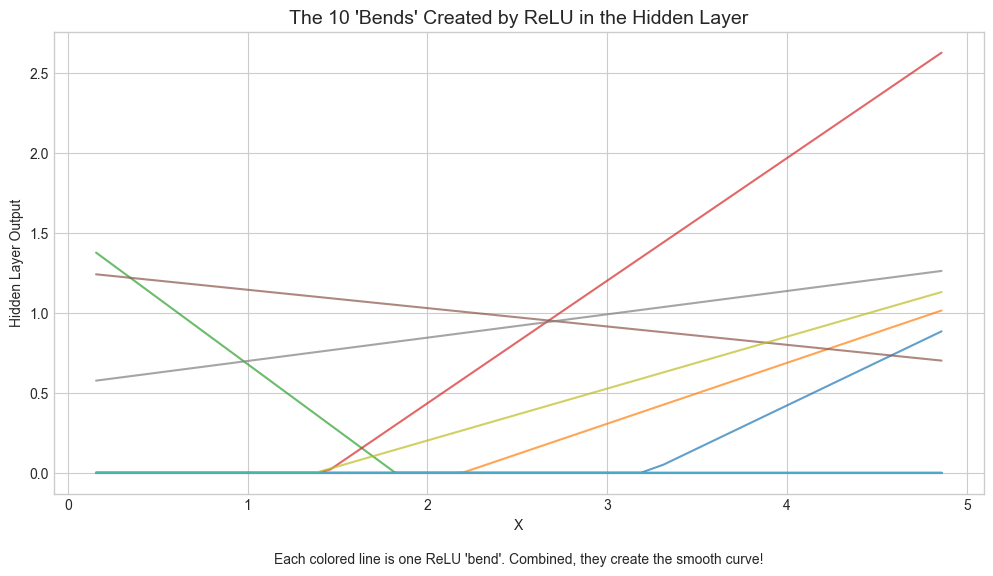

In [23]:
# Let's see what the hidden layer outputs look like
# We pass the sorted test data through the FIRST layer only
with torch.no_grad():
    X_test_sorted_t = torch.tensor(scaler_X.transform(X_test_sorted), dtype=torch.float32)
    hidden_outputs = model.hidden(X_test_sorted_t)  # Output of the 10 neurons (before ReLU)
    hidden_outputs = model.activation(hidden_outputs)  # After ReLU

# Plot the 10 "bends" created by the hidden layer
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(X_test_sorted.ravel(), hidden_outputs[:, i].numpy(), 
             linewidth=1.5, alpha=0.7, label=f'Neuron {i+1}')

plt.title("The 10 'Bends' Created by ReLU in the Hidden Layer", fontsize=14)
plt.xlabel("X")
plt.ylabel("Hidden Layer Output")
plt.grid(True)
# Don't show all 10 legend entries (too cluttered), just show a note
plt.text(0.5, -0.15, "Each colored line is one ReLU 'bend'. Combined, they create the smooth curve!", 
         transform=plt.gca().transAxes, ha='center', fontsize=10)
plt.show()

## 4.5 BONUS: What happens if we set the Learning Rate too big? (Slide 14)

Let's visually prove that a **Too Big** learning rate causes chaos, while the **Just Right** one converges smoothly.

Training with Learning Rate = 0.5 (Too Big!)...


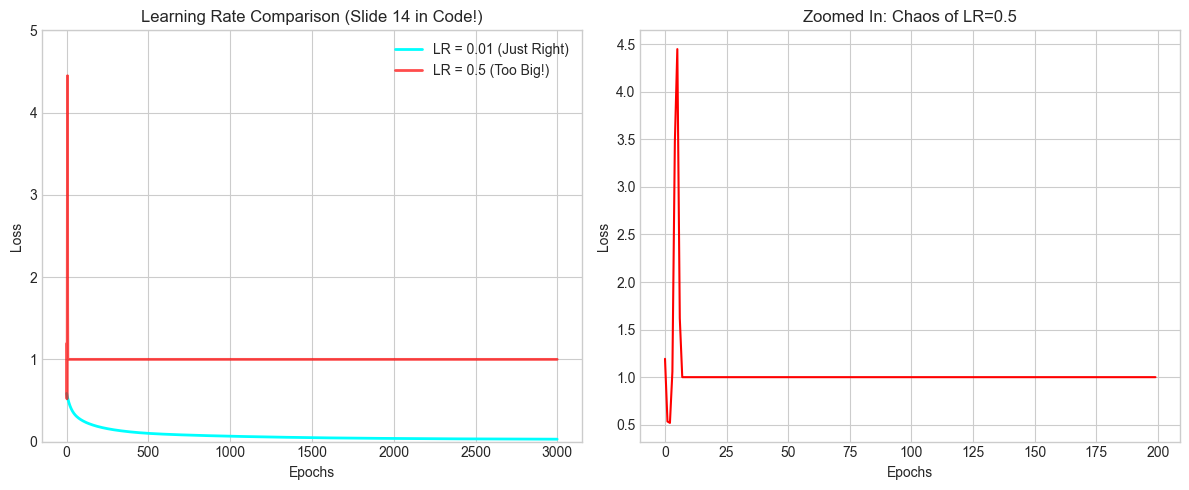

Notice how LR=0.5 oscillates wildly and never properly converges.
This perfectly demonstrates Slide 14: 'Too Big = Chaos'!


In [24]:
# Create a new model with a HUGE learning rate
model_bad = SimpleNN()
optimizer_bad = torch.optim.SGD(model_bad.parameters(), lr=0.5)  # Too Big!
loss_bad = []

print("Training with Learning Rate = 0.5 (Too Big!)...")
for epoch in range(3000):
    preds = model_bad(X_train_t)
    loss = criterion(preds, y_train_t)
    optimizer_bad.zero_grad()
    loss.backward()
    optimizer_bad.step()
    loss_bad.append(loss.item())

# Plot the comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, color='cyan', linewidth=2, label='LR = 0.01 (Just Right)')
plt.plot(loss_bad, color='red', linewidth=2, alpha=0.7, label='LR = 0.5 (Too Big!)')
plt.title("Learning Rate Comparison (Slide 14 in Code!)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.ylim(0, 5)  # Zoom in to see the chaos

plt.subplot(1, 2, 2)
plt.plot(loss_bad[:200], color='red')
plt.title("Zoomed In: Chaos of LR=0.5")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Notice how LR=0.5 oscillates wildly and never properly converges.")
print("This perfectly demonstrates Slide 14: 'Too Big = Chaos'!")